In [14]:
# ============================================================================
# SARIMA TIME SERIES FORECASTING
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import itertools

# 1. DATA LOADING & PREPROCESSING

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
print("\n[STEP 1] Load Data Set Dan Preprocessing Data...")

# Load dataset
# df_sales = pd.read_csv('store5.csv')
df_sales = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FinalProject1-ForecastingArimaLstm/store5.csv')

# Convert date and filter
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_filtered = df_sales[
    (df_sales['date'] >= '2013-01-01') &
    (df_sales['date'] <= '2017-12-31')
].copy()

# Create holiday indicator
df_filtered['is_holiday'] = (df_filtered['sales'] == 0).astype(int)

# Daily aggregation
df_daily = df_filtered.groupby('date').agg({
    'sales': 'sum',
    'is_holiday': 'max'
}).asfreq('D').fillna(0)

df_daily['is_holiday'] = df_daily['is_holiday'].astype(int)

df_daily



[STEP 1] Load Data Set Dan Preprocessing Data...


,sales,is_holiday
date,,
2013-01-01,0.000000,1
2013-01-02,10598.619020,1
2013-01-03,7770.968000,1
2013-01-04,7347.641991,1
2013-01-05,8192.598000,1
...,...,...
2017-08-11,9510.871000,1
2017-08-12,8157.070000,1
2017-08-13,10044.821000,1


# 2. EXPLORATORY DATA ANALYSIS


[STEP 2] Exploratory Data Analysis...


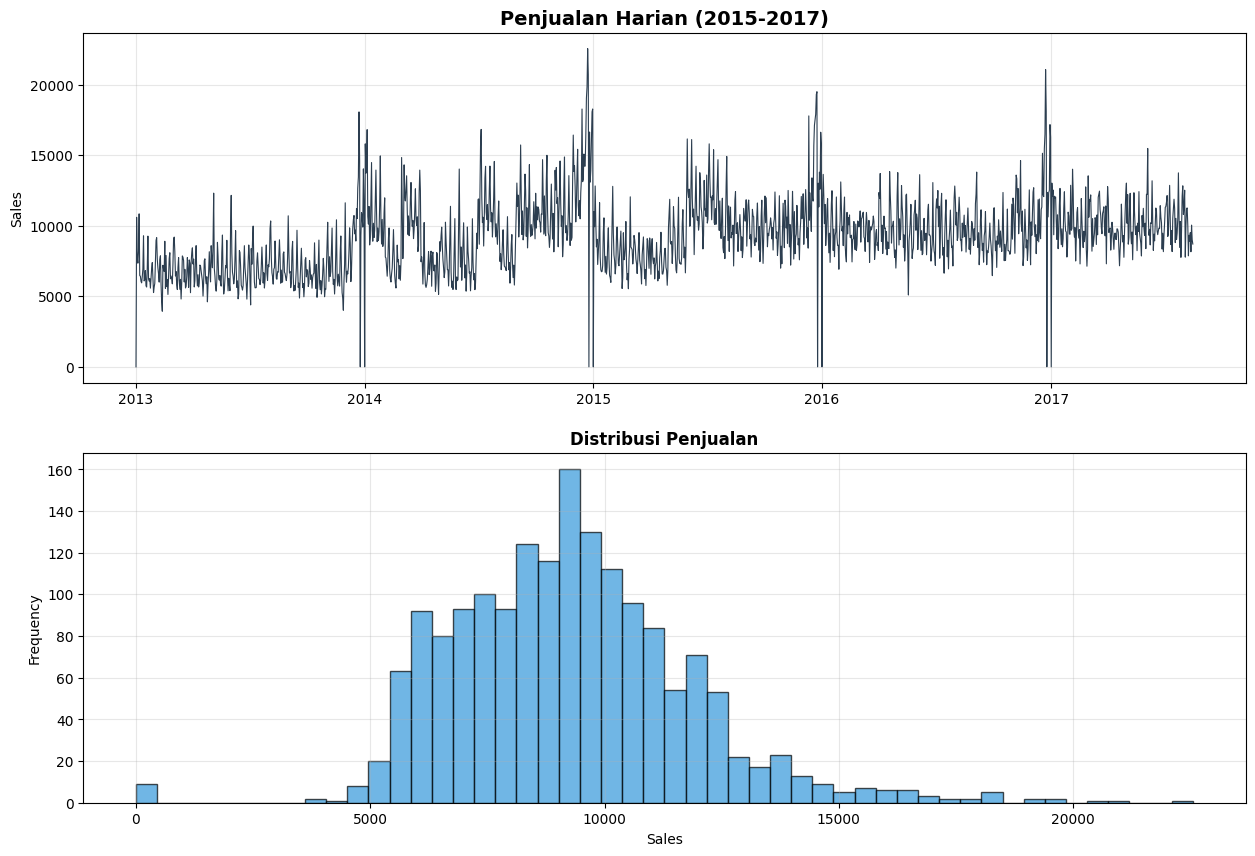

In [17]:
# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS
# ============================================================================
print("\n[STEP 2] Exploratory Data Analysis...")

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Time series
axes[0].plot(df_daily.index, df_daily['sales'], color='#2c3e50', linewidth=0.8)
axes[0].set_title('Penjualan Harian (2015-2017)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution
axes[1].hist(df_daily['sales'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Penjualan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sales')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.show()



# 3. STATIONARITY TESTS

In [18]:
# ============================================================================
# 3. STATIONARITY TESTS
# ============================================================================
print("\n[STEP 3] Stationarity Testing...")

def adf_test(series, name=''):
    """Perform Augmented Dickey-Fuller test"""
    result = adfuller(series.dropna())
    print(f"\n--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Lags used: {result[2]}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.3f}")

    if result[1] <= 0.05:
        print("✓ STATIONARY (p < 0.05)")
        return True
    else:
        print("✗ NON-STATIONARY (p >= 0.05)")
        return False

# Test original series
is_stationary = adf_test(df_daily['sales'], 'Original Series')

# Test first difference (if needed)
if not is_stationary:
    print("\nTesting first difference...")
    diff_1 = df_daily['sales'].diff().dropna()
    adf_test(diff_1, 'First Difference')

# Test seasonal difference - IMPROVEMENT #8
print("\nTesting seasonal difference (lag=7)...")
seasonal_diff = df_daily['sales'].diff(7).dropna()
is_seasonal_stationary = adf_test(seasonal_diff, 'Seasonal Difference (7-day)')


[STEP 3] Stationarity Testing...

--- ADF Test: Original Series ---
ADF Statistic: -4.7745
p-value: 0.0001
Lags used: 23
Critical Values:
  1%: -3.434
  5%: -2.863
  10%: -2.568
✓ STATIONARY (p < 0.05)

Testing seasonal difference (lag=7)...

--- ADF Test: Seasonal Difference (7-day) ---
ADF Statistic: -11.1635
p-value: 0.0000
Lags used: 21
Critical Values:
  1%: -3.434
  5%: -2.863
  10%: -2.568
✓ STATIONARY (p < 0.05)


# 4. DECOMPOSITION


[STEP 4] Seasonal Decomposition...


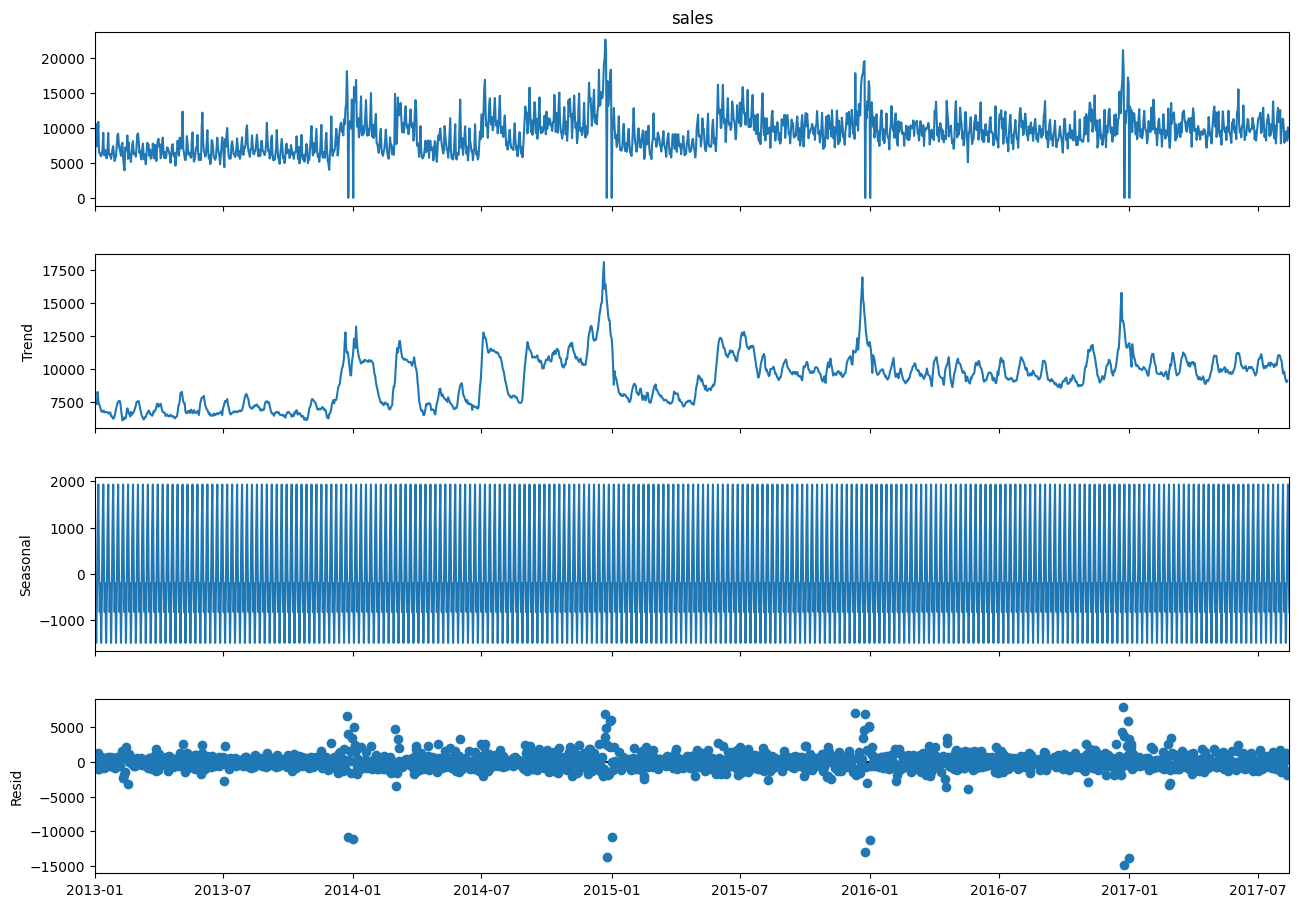

In [19]:
# ============================================================================
# 4. DECOMPOSITION
# ============================================================================
print("\n[STEP 4] Seasonal Decomposition...")

result_decomp = seasonal_decompose(
    df_daily['sales'],
    model='additive',
    period=7
)

fig = result_decomp.plot()
fig.set_size_inches(15, 10)
plt.show()


# 5. ACF & PACF ANALYSIS


[STEP 5] ACF & PACF Analysis...


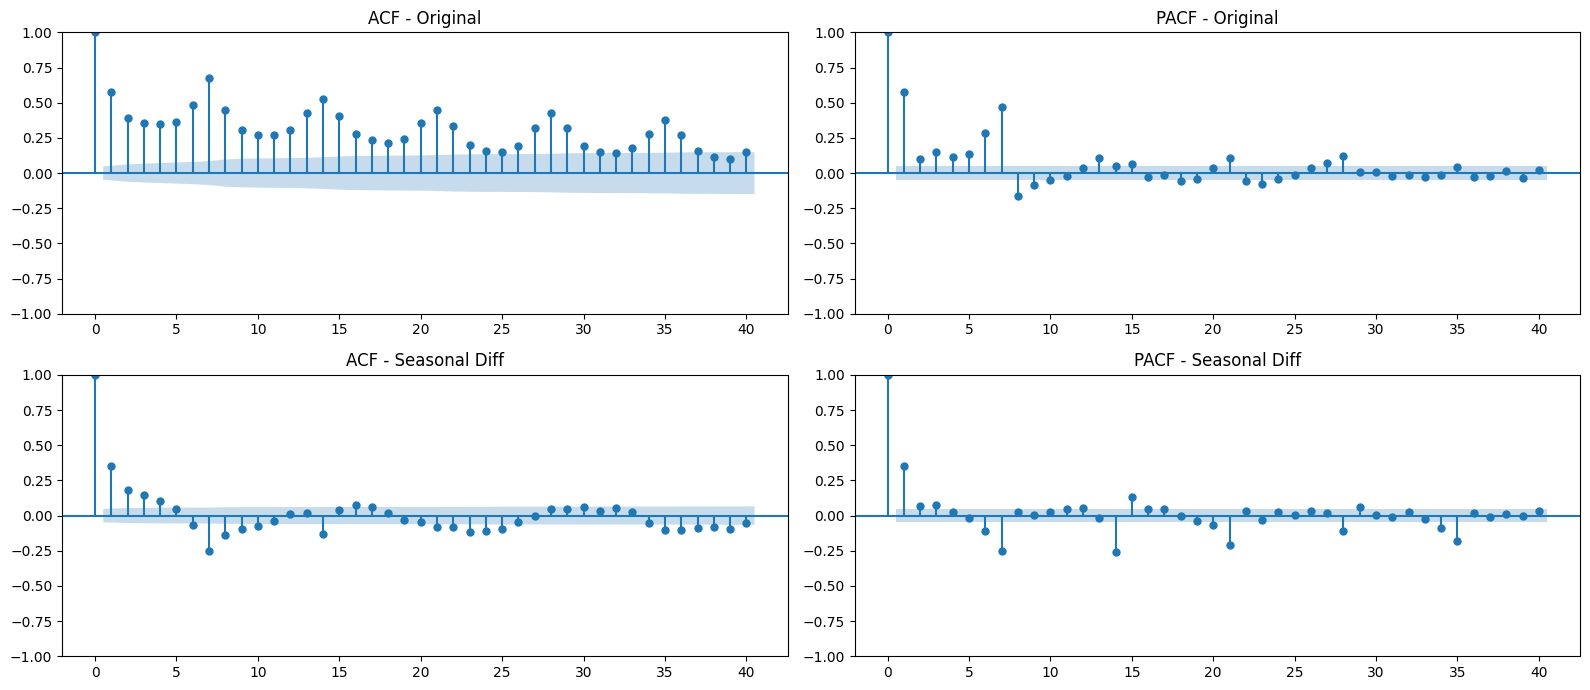

In [20]:
print("\n[STEP 5] ACF & PACF Analysis...")

fig, axes = plt.subplots(2, 2, figsize=(16, 7))

# Original series
plot_acf(df_daily['sales'], lags=40, ax=axes[0,0], title="ACF - Original")
plot_pacf(df_daily['sales'], lags=40, ax=axes[0,1], title="PACF - Original")

# Seasonal differenced
plot_acf(seasonal_diff, lags=40, ax=axes[1,0], title="ACF - Seasonal Diff")
plot_pacf(seasonal_diff, lags=40, ax=axes[1,1], title="PACF - Seasonal Diff")

plt.tight_layout()
plt.show()

# 6. FEATURE ENGINEERING

In [21]:
print("\n[NEW STEP] Advanced Feature Engineering...")

# Log transform sales
df_daily['log_sales'] = np.log1p(df_daily['sales'])

# Lag features
df_daily['lag_7'] = df_daily['sales'].shift(7)
df_daily['lag_14'] = df_daily['sales'].shift(14)

# Rolling statistics
df_daily['rolling_mean_7'] = df_daily['sales'].rolling(7).mean()
df_daily['rolling_std_7'] = df_daily['sales'].rolling(7).std()

# Fill missing values
df_daily.fillna(method='bfill', inplace=True)

# Exogenous variables
exog_features = [
    'is_holiday',
    'lag_7',
    'lag_14',
    'rolling_mean_7'
]


[NEW STEP] Advanced Feature Engineering...


# 7. VALIDATE EXOGENOUS VARIABLES

In [22]:

print("\n[STEP 7] Validating Exogenous Variables...")

# Check correlation between sales and features
correlations = df_daily[['sales'] + exog_features].corr()

print("\nCorrelation Matrix:")
print(correlations)

# Test a simple model with exogenous variables
print("\nTesting significance of exogenous variables...")

# Prepare data
y_temp = df_daily['sales'][:1000]

exog_temp = df_daily[exog_features][:1000]

model_exog_test = SARIMAX(
    y_temp,
    exog=exog_temp,
    order=(1,0,1),
    seasonal_order=(0,0,0,0)
).fit(disp=False)

print("\nExogenous Variable Significance (p-values):")
print(model_exog_test.pvalues)

print("\nNote: p-value < 0.05 indicates significant variable")


[STEP 7] Validating Exogenous Variables...

Correlation Matrix:
                   sales  is_holiday     lag_7    lag_14  rolling_mean_7
sales           1.000000    0.176268  0.672029  0.523413        0.701134
is_holiday      0.176268    1.000000 -0.061458 -0.046932       -0.130022
lag_7           0.672029   -0.061458  1.000000  0.689018        0.635315
lag_14          0.523413   -0.046932  0.689018  1.000000        0.513951
rolling_mean_7  0.701134   -0.130022  0.635315  0.513951        1.000000

Testing significance of exogenous variables...

Exogenous Variable Significance (p-values):
is_holiday         1.459344e-01
lag_7             4.903682e-193
lag_14             2.843270e-03
rolling_mean_7    1.401686e-118
ar.L1              9.063531e-06
ma.L1              9.263029e-02
sigma2            9.341863e-281
dtype: float64

Note: p-value < 0.05 indicates significant variable


# 8. GRID SEARCH FOR OPTIMAL PARAMETERS

In [23]:
print("\n[STEP 7] Grid Search for Optimal Parameters...")

# Define parameter ranges
# p = d = q = range(0, 3)
# P = D = Q = range(0, 2)
# s = 7

p = range(0,3)
d = [1]
q = range(0,3)

P = range(0,2)
D = [1]
Q = range(0,2)

s = 7

# Use a subset for faster grid search
train_size_gs = int(len(df_daily) * 0.7)
y_gs = df_daily['sales'][:train_size_gs]
# exog_gs = df_daily[['is_holiday', 'is_weekend']][:train_size_gs]
exog_gs = df_daily[exog_features][:train_size_gs]

results_grid = []
best_aic = float("inf")
best_params = None

total_combinations = len(list(itertools.product(p, d, q))) * len(list(itertools.product(P, D, Q)))
current = 0

for param in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q):
        current += 1
        try:
            model = SARIMAX(
                y_gs,
                exog=exog_gs,
                order=param,
                seasonal_order=(seasonal[0], seasonal[1], seasonal[2], s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False, maxiter=50)

            results_grid.append({
                'order': param,
                'seasonal': (seasonal[0], seasonal[1], seasonal[2], s),
                'AIC': result.aic,
                'BIC': result.bic
            })

            if result.aic < best_aic:
                best_aic = result.aic
                best_params = {
                    'order': param,
                    'seasonal': (seasonal[0], seasonal[1], seasonal[2], s)
                }

            if current % 10 == 0:
                print(f"Progress: {current}/{total_combinations} combinations tested...")

        except Exception as e:
            continue

print("\n" + "="*60)
print("GRID SEARCH RESULTS")
print("="*60)
print(f"Best Order: {best_params['order']}")
print(f"Best Seasonal: {best_params['seasonal']}")
print(f"Best AIC: {best_aic:.2f}")
print("="*60)

# Show top 5 models
df_results = pd.DataFrame(results_grid).sort_values('AIC').head(10)
print("\nTop 10 Models by AIC:")
print(df_results.to_string(index=False))


[STEP 7] Grid Search for Optimal Parameters...
Progress: 10/36 combinations tested...
Progress: 20/36 combinations tested...
Progress: 30/36 combinations tested...

GRID SEARCH RESULTS
Best Order: (1, 1, 1)
Best Seasonal: (0, 1, 1, 7)
Best AIC: 20047.30

Top 10 Models by AIC:
    order     seasonal          AIC          BIC
(1, 1, 1) (0, 1, 1, 7) 20047.295514 20087.772455
(0, 1, 2) (1, 1, 1, 7) 20058.165144 20103.693968
(0, 1, 1) (0, 1, 1, 7) 20155.122133 20190.539456
(0, 1, 1) (1, 1, 1, 7) 20179.378352 20219.855293
(2, 1, 2) (0, 1, 1, 7) 20179.676014 20230.263596
(2, 1, 0) (1, 1, 1, 7) 20192.029316 20237.565875
(1, 1, 2) (0, 1, 1, 7) 20229.300992 20274.829815
(2, 1, 2) (1, 1, 1, 7) 20229.343953 20284.990293
(1, 1, 2) (1, 1, 1, 7) 20230.031856 20280.619437
(0, 1, 2) (0, 1, 1, 7) 20235.417777 20275.887842


# 9. TRAIN-TEST SPLIT

In [24]:
print("\n[STEP 9] Train-Test Split...")

# Use 80-20 split consistently
split_point = int(len(df_daily) * 0.8)

train_y = df_daily['sales'][:split_point]
test_y = df_daily['sales'][split_point:]

# train_exog = df_daily[['is_holiday', 'is_weekend']][:split_point]
# test_exog = df_daily[['is_holiday', 'is_weekend']][split_point:]

train_exog = df_daily[exog_features][:split_point]
test_exog = df_daily[exog_features][split_point:]

print(f"✓ Training set: {len(train_y)} days ({train_y.index.min()} to {train_y.index.max()})")
print(f"✓ Testing set: {len(test_y)} days ({test_y.index.min()} to {test_y.index.max()})")


[STEP 9] Train-Test Split...
✓ Training set: 1350 days (2013-01-01 00:00:00 to 2016-09-11 00:00:00)
✓ Testing set: 338 days (2016-09-12 00:00:00 to 2017-08-15 00:00:00)


# 10. MODEL FITTING WITH BEST PARAMETERS

In [25]:
print("\n[STEP 9] Fitting SARIMA Model with Best Parameters...")

# Use best parameters from grid search
final_model = SARIMAX(
    train_y,
    exog=train_exog,
    order=best_params['order'],
    seasonal_order=best_params['seasonal'],
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit(disp=False)

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(final_fit.summary())


[STEP 9] Fitting SARIMA Model with Best Parameters...

MODEL SUMMARY
                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1350
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -11456.716
Date:                           Fri, 13 Mar 2026   AIC                          22929.432
Time:                                   12:30:24   BIC                          22970.994
Sample:                               01-01-2013   HQIC                         22945.007
                                    - 09-11-2016                                         
Covariance Type:                             opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
is_holiday      5385.4292    213.857     25.

# 11. DIAGNOSTIC CHECKING


[STEP 10] Model Diagnostics...


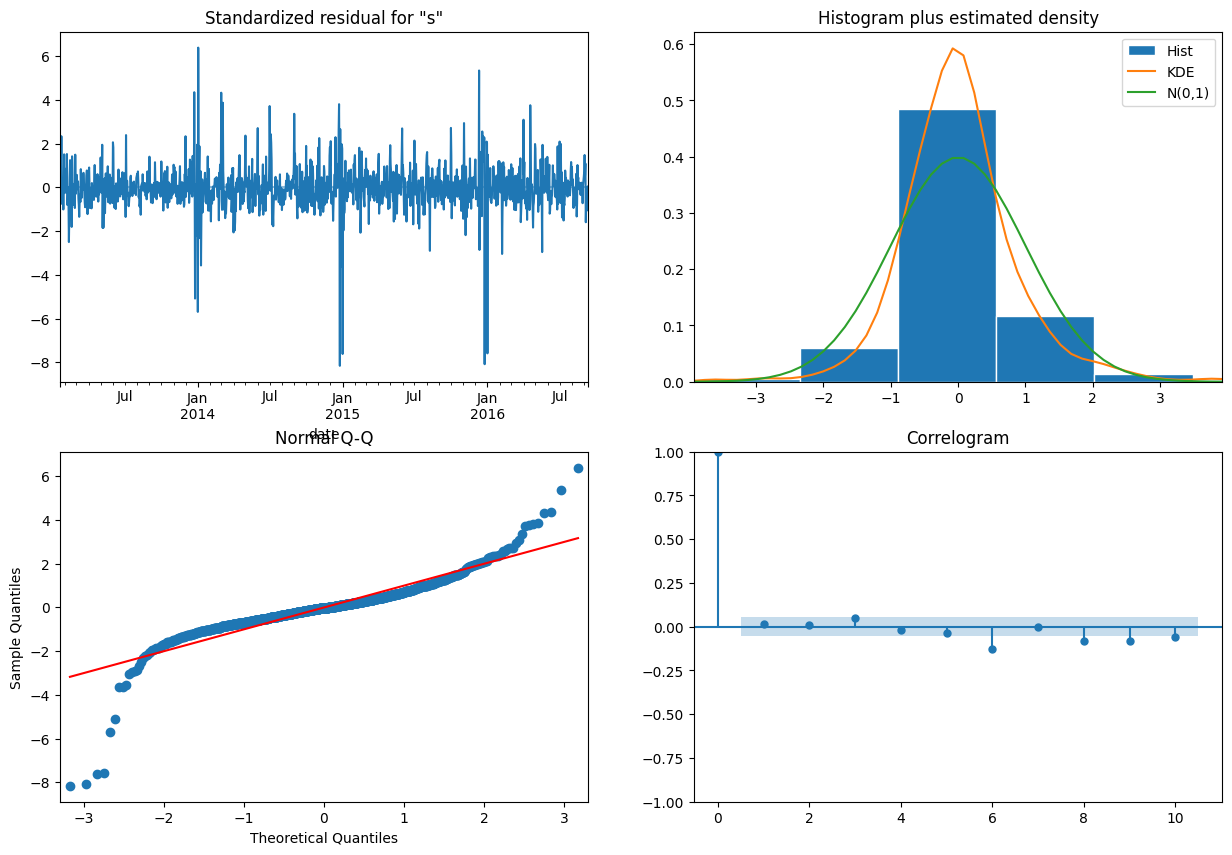


Ljung-Box Test (Residual Autocorrelation):
      lb_stat  lb_pvalue
10  37.529607   0.000046
20  47.338971   0.000526
30  71.453144   0.000031

Note: p-value > 0.05 indicates no significant autocorrelation (GOOD)


In [26]:
print("\n[STEP 10] Model Diagnostics...")

# Diagnostic plots
fig = final_fit.plot_diagnostics(figsize=(15, 10))
plt.show()

# Ljung-Box test for residual autocorrelation
lb_test = acorr_ljungbox(final_fit.resid, lags=[10, 20, 30], return_df=True)
print("\nLjung-Box Test (Residual Autocorrelation):")
print(lb_test)
print("\nNote: p-value > 0.05 indicates no significant autocorrelation (GOOD)")

# 12. BASELINE MODEL COMPARISON

In [27]:
print("\n[STEP 12] Baseline Model Comparison...")

# Naive forecast (last value)
naive_forecast = np.full(len(test_y), train_y.iloc[-1])
naive_mae = mean_absolute_error(test_y, naive_forecast)

# Seasonal naive (same day last week)
seasonal_naive_forecast = train_y.iloc[-7:].values
seasonal_naive_forecast = np.tile(seasonal_naive_forecast, len(test_y) // 7 + 1)[:len(test_y)]
seasonal_naive_mae = mean_absolute_error(test_y, seasonal_naive_forecast)

# Moving average (7-day)
ma_forecast = train_y.rolling(window=7).mean().iloc[-1]
ma_forecast = np.full(len(test_y), ma_forecast)
ma_mae = mean_absolute_error(test_y, ma_forecast)

print("\nBaseline Models Performance (MAE):")
print(f"  Naive Forecast: {naive_mae:.2f}")
print(f"  Seasonal Naive: {seasonal_naive_mae:.2f}")
print(f"  Moving Average (7-day): {ma_mae:.2f}")


[STEP 12] Baseline Model Comparison...

Baseline Models Performance (MAE):
  Naive Forecast: 1786.43
  Seasonal Naive: 1348.55
  Moving Average (7-day): 1521.33


# 13. MODEL PREDICTION & EVALUATION

In [28]:
print("\n[STEP 13] Model Prediction & Evaluation...")

# Forecast
forecast_obj = final_fit.get_forecast(steps=len(test_y), exog=test_exog)
forecast_df = forecast_obj.summary_frame()
y_pred = forecast_df['mean']

# Calculate metrics
mae = mean_absolute_error(test_y, y_pred)
mse = mean_squared_error(test_y, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test_y, y_pred) * 100

# Calculate improvement over baseline
improvement_vs_naive = ((naive_mae - mae) / naive_mae) * 100
improvement_vs_seasonal = ((seasonal_naive_mae - mae) / seasonal_naive_mae) * 100

print("\n" + "="*60)
print("SARIMA MODEL PERFORMANCE")
print("="*60)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print("\n" + "="*60)
print("IMPROVEMENT OVER BASELINES")
print("="*60)
print(f"vs Naive Forecast: {improvement_vs_naive:+.2f}%")
print(f"vs Seasonal Naive: {improvement_vs_seasonal:+.2f}%")
print("="*60)


[STEP 13] Model Prediction & Evaluation...

SARIMA MODEL PERFORMANCE
MAE  : 901.84
MSE  : 2000019.35
RMSE : 1414.22
MAPE : 27176388001692540928.00%

IMPROVEMENT OVER BASELINES
vs Naive Forecast: +49.52%
vs Seasonal Naive: +33.13%


# 14. TIME SERIES CROSS-VALIDATION

In [29]:
print("\n[STEP 14] Time Series Cross-Validation...")

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_daily)):
    print(f"  Fold {fold + 1}/5...", end=" ")

    # Split data
    cv_train_y = df_daily['sales'].iloc[train_idx]
    cv_test_y = df_daily['sales'].iloc[test_idx]
    # cv_train_exog = df_daily[['is_holiday', 'is_weekend']].iloc[train_idx]
    # cv_test_exog = df_daily[['is_holiday', 'is_weekend']].iloc[test_idx]
    cv_train_exog = df_daily[exog_features].iloc[train_idx]
    cv_test_exog = df_daily[exog_features].iloc[test_idx]

    # Fit model
    try:
        cv_model = SARIMAX(
            cv_train_y,
            exog=cv_train_exog,
            order=best_params['order'],
            seasonal_order=best_params['seasonal'],
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=50)

        # Predict
        cv_pred = cv_model.get_forecast(steps=len(cv_test_y), exog=cv_test_exog).predicted_mean

        # Calculate MAE
        cv_mae = mean_absolute_error(cv_test_y, cv_pred)
        cv_scores.append(cv_mae)
        print(f"MAE = {cv_mae:.2f}")

    except Exception as e:
        print(f"Failed: {str(e)}")
        continue

if cv_scores:
    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS")
    print("="*60)
    print(f"Mean MAE: {np.mean(cv_scores):.2f} (±{np.std(cv_scores):.2f})")
    print(f"Min MAE: {np.min(cv_scores):.2f}")
    print(f"Max MAE: {np.max(cv_scores):.2f}")
    print("="*60)


[STEP 14] Time Series Cross-Validation...
  Fold 1/5... MAE = 1021.85
  Fold 2/5... MAE = 953.07
  Fold 3/5... MAE = 971.22
  Fold 4/5... MAE = 881.89
  Fold 5/5... MAE = 979.34

CROSS-VALIDATION RESULTS
Mean MAE: 961.47 (±45.75)
Min MAE: 881.89
Max MAE: 1021.85


# 15. ERROR ANALYSIS


[STEP 14] Error Analysis...


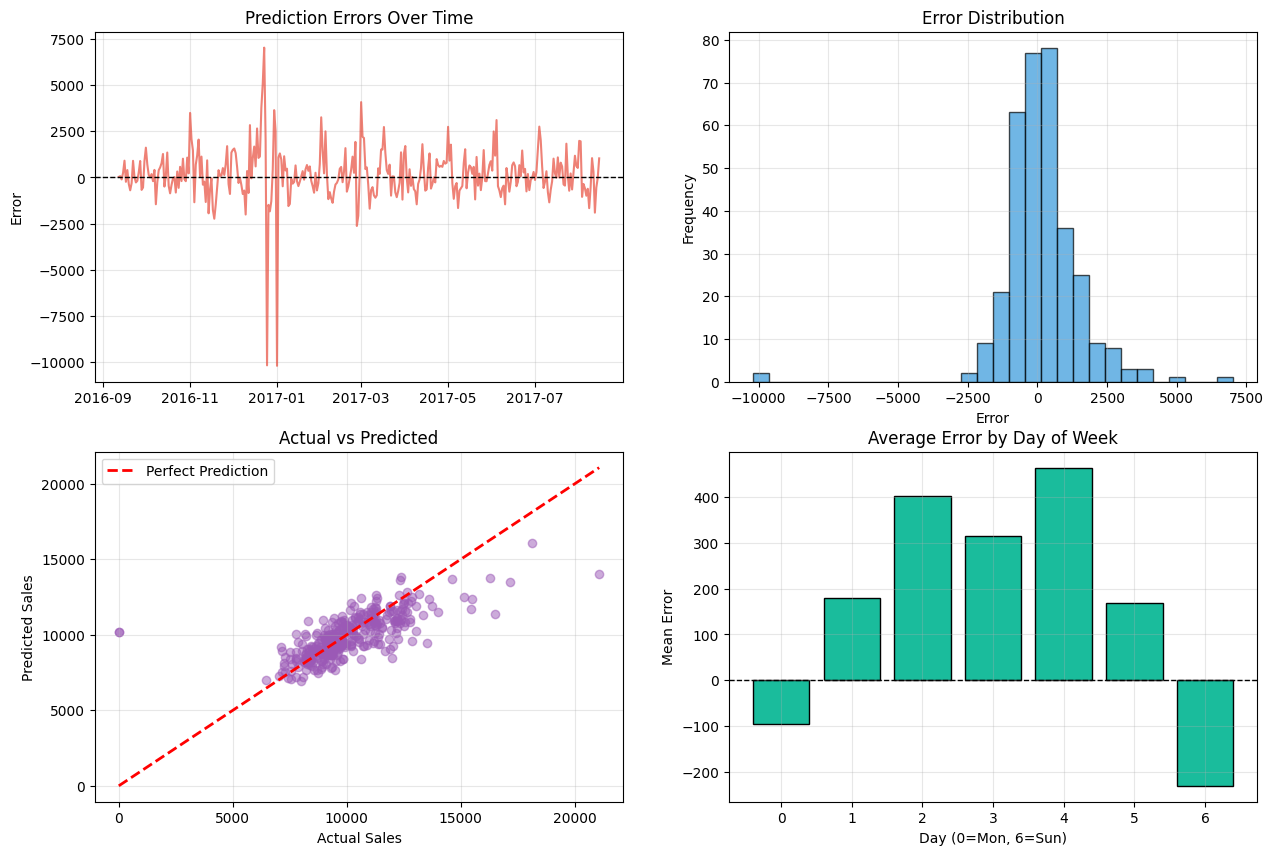

In [30]:
print("\n[STEP 14] Error Analysis...")

errors = test_y - y_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Error over time
axes[0, 0].plot(test_y.index, errors, color='#e74c3c', alpha=0.7)
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Prediction Errors Over Time')
axes[0, 0].set_ylabel('Error')
axes[0, 0].grid(True, alpha=0.3)

# Error distribution
axes[0, 1].hist(errors, bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Error Distribution')
axes[0, 1].set_xlabel('Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted scatter
axes[1, 0].scatter(test_y, y_pred, alpha=0.5, color='#9b59b6')
axes[1, 0].plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()],
                'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Sales')
axes[1, 0].set_ylabel('Predicted Sales')
axes[1, 0].set_title('Actual vs Predicted')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error by day of week
error_by_dow = pd.DataFrame({
    'error': errors,
    'day_of_week': test_y.index.dayofweek
}).groupby('day_of_week')['error'].mean()

axes[1, 1].bar(range(7), error_by_dow.values, color='#1abc9c', edgecolor='black')
axes[1, 1].set_title('Average Error by Day of Week')
axes[1, 1].set_xlabel('Day (0=Mon, 6=Sun)')
axes[1, 1].set_ylabel('Mean Error')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1, 1].grid(True, alpha=0.3)

plt.show()


# 16. VISUALIZATION: ACTUAL VS FORECAST


[STEP 15] Creating Visualization...


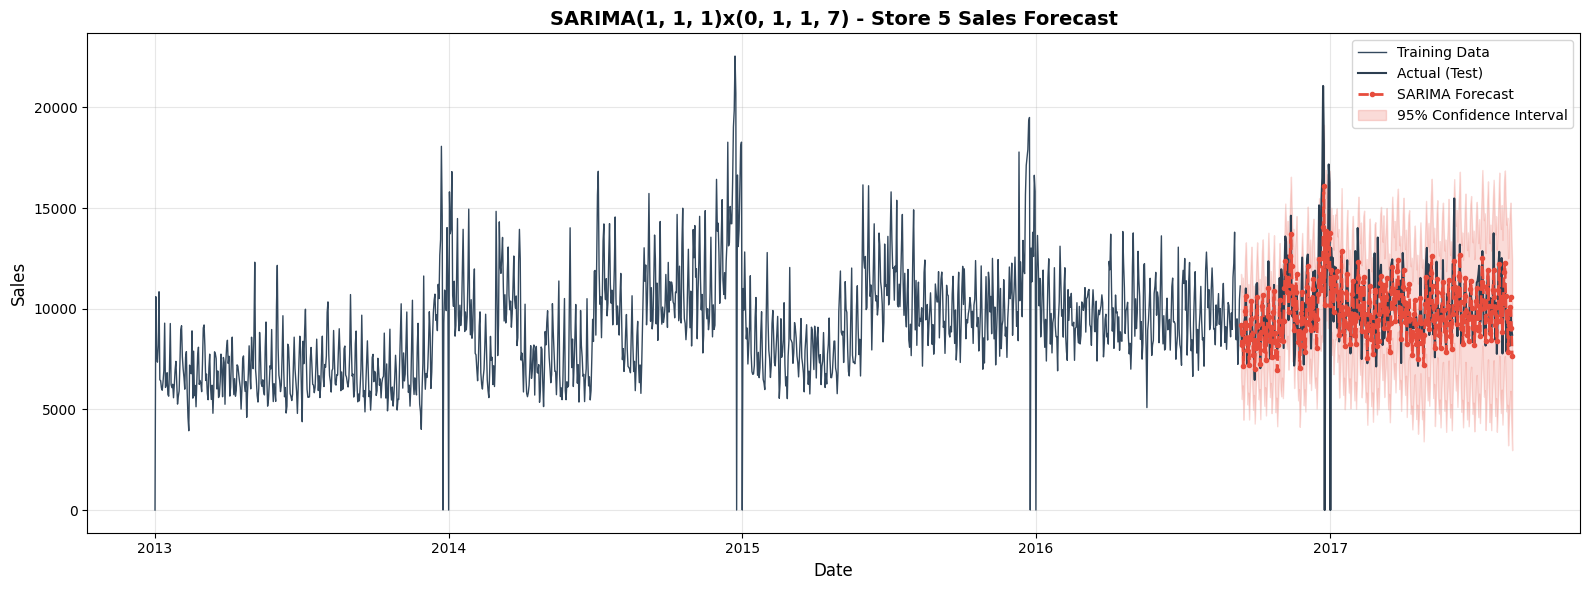

In [31]:
print("\n[STEP 15] Creating Visualization...")

fig, ax = plt.subplots(figsize=(16, 6))

# Plot training data
ax.plot(train_y.index, train_y, label='Training Data', color='#34495e', linewidth=1)

# Plot test data
ax.plot(test_y.index, test_y, label='Actual (Test)', color='#2c3e50', linewidth=1.5)

# Plot predictions
ax.plot(test_y.index, y_pred, label='SARIMA Forecast',
        color='#e74c3c', linestyle='--', linewidth=2, marker='o', markersize=3)

# Confidence interval
ax.fill_between(test_y.index,
                forecast_df['mean_ci_lower'],
                forecast_df['mean_ci_upper'],
                color='#e74c3c', alpha=0.2, label='95% Confidence Interval')

ax.set_title(f'SARIMA{best_params["order"]}x{best_params["seasonal"]} - Store 5 Sales Forecast',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 17. FUTURE FORECAST (30 DAYS)


[STEP 16] Generating 30-Day Future Forecast...

7-Day Forecast Preview:
2017-08-16    1066.227312
2017-08-17    -636.901524
2017-08-18     738.562273
2017-08-19    1776.462428
2017-08-20    2413.703276
2017-08-21     927.829317
2017-08-22       7.568134
Freq: D


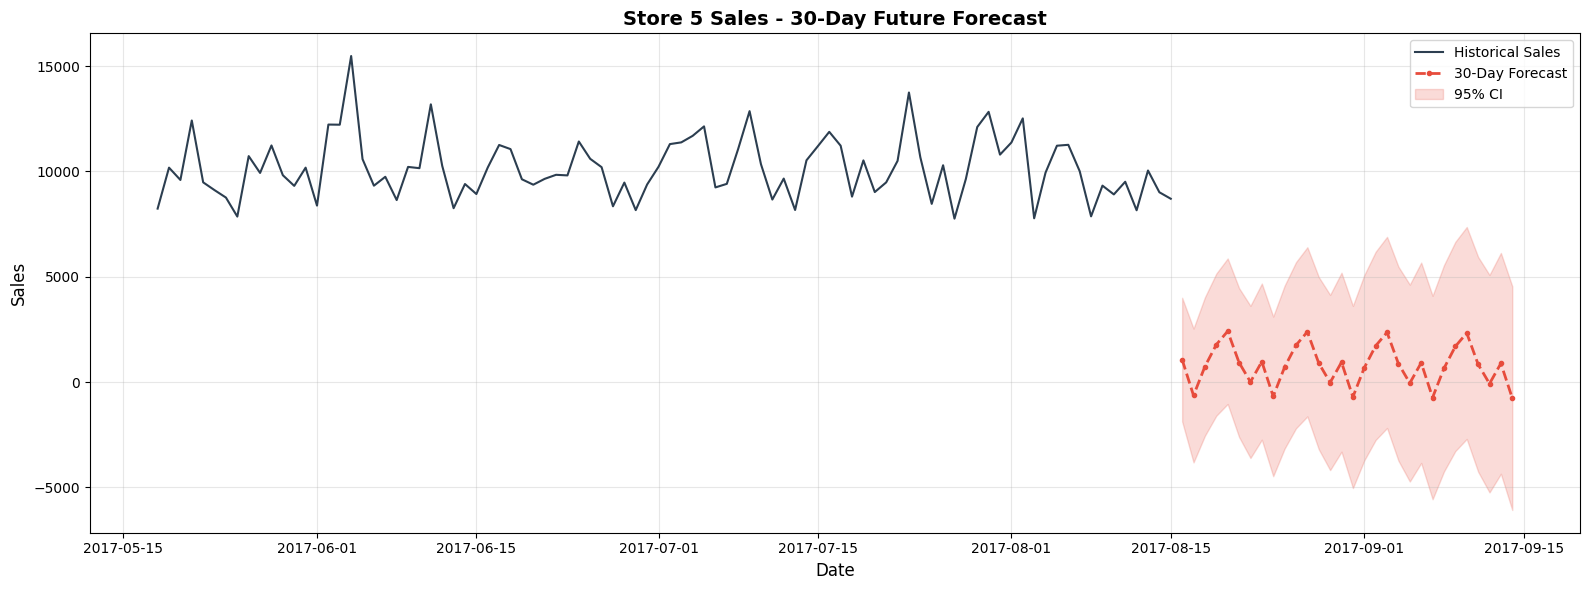

In [32]:
print("\n[STEP 16] Generating 30-Day Future Forecast...")

# Refit model on full dataset
full_model = SARIMAX(
    df_daily['sales'],
    exog=df_daily[['is_holiday']],
    order=best_params['order'],
    seasonal_order=best_params['seasonal'],
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Create future dates
future_dates = pd.date_range(
    start=df_daily.index[-1] + pd.Timedelta(days=1),
    periods=30
)

# Create realistic exogenous variables - IMPROVEMENT #5
future_exog = pd.DataFrame(index=future_dates)

# Assume holidays follow weekly pattern (can be customized)
future_exog['is_holiday'] = 0  # Set to 1 for known future holidays

# Get forecast
future_forecast_obj = full_model.get_forecast(
    steps=30,
    # exog=future_exog[['is_holiday', 'is_weekend']]
    exog=future_exog[['is_holiday']]
)
future_forecast_df = future_forecast_obj.summary_frame()

print("\n7-Day Forecast Preview:")
print(future_forecast_df['mean'].head(7).to_string())

# Visualization
fig, ax = plt.subplots(figsize=(16, 6))

# Historical data (last 90 days)
recent_data = df_daily['sales'][-90:]
ax.plot(recent_data.index, recent_data, label='Historical Sales',
        color='#2c3e50', linewidth=1.5)

# Future forecast
ax.plot(future_forecast_df.index, future_forecast_df['mean'],
        label='30-Day Forecast', color='#e74c3c', linestyle='--',
        linewidth=2, marker='o', markersize=3)

# Confidence interval
ax.fill_between(future_forecast_df.index,
                future_forecast_df['mean_ci_lower'],
                future_forecast_df['mean_ci_upper'],
                color='#e74c3c', alpha=0.2, label='95% CI')

ax.set_title('Store 5 Sales - 30-Day Future Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
